In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
df = pd.read_csv('Social_Network_Ads.csv')

In [89]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [90]:
df = df.iloc[: , 2:]

In [91]:
df.sample(5)

,Age,EstimatedSalary,Purchased
221,35,91000,1
364,42,104000,1
305,42,54000,0
99,28,37000,0
304,40,60000,0


# Train test split

In [92]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop('Purchased' , axis = 1), df['Purchased'], test_size = 0.3, random_state = 0)

In [93]:
x_train.shape , x_test.shape

((280, 2), (120, 2))

# StandardScalar

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scalar to train set , it will learn parameters
scaler.fit(x_train)

# transform train and test set
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [95]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [96]:
x_train_scaled = pd.DataFrame(x_train_scaled , columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns = x_test.columns)

In [97]:
np.round(x_train.describe() ,1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [98]:
x_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [99]:
np.round(x_train_scaled.describe() , 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


# Effect of scaling

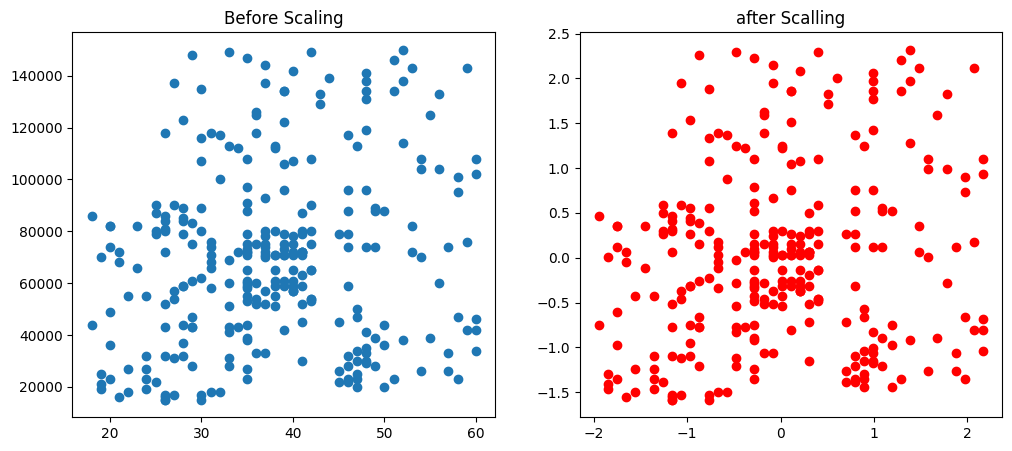

In [100]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2, figsize=(12,5))

ax1.scatter(x_train['Age'] , x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'] , x_train_scaled['EstimatedSalary'] , color = 'red')
ax2.set_title("after Scalling")
plt.show()

# Why scaling is important?

In [101]:
from sklearn.linear_model import LogisticRegression

In [102]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [103]:
lr.fit(x_train ,y_train)
lr_scaled.fit(x_train_scaled , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [104]:
y_pred = lr.predict(x_test)
y_pred_scaled = lr_scaled.predict(x_test_scaled)

In [105]:
from sklearn.metrics import accuracy_score

In [106]:
print("Actual" , accuracy_score(y_test , y_pred)*100)
print("Scaled" , accuracy_score(y_test , y_pred_scaled)*100)

Actual 87.5
Scaled 86.66666666666667


In [107]:
df.describe()


,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [108]:
new_rows = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

df = pd.concat([df, new_rows], ignore_index=True)

In [109]:
df.shape

(403, 3)

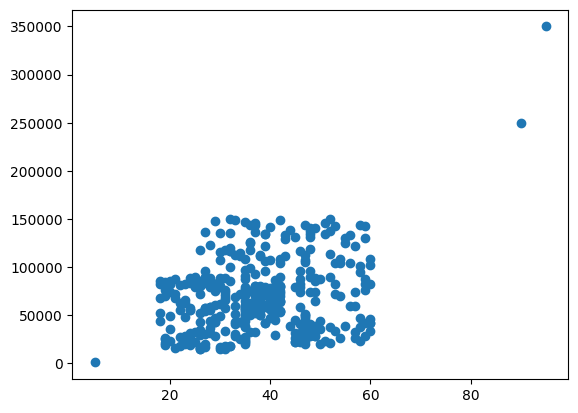

In [110]:
plt.scatter(df['Age'] , df['EstimatedSalary'])

In [111]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(df.drop('Purchased' , axis = 1), df['Purchased'], test_size = 0.3, random_state = 0)

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit the scalar to train set , it will learn parameters
scaler.fit(x_train)

# transform train ans test set
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [113]:
x_train_scaled = pd.DataFrame(x_train_scaled , columns = x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled , columns = x_test.columns)

In [114]:
np.round(x_train.describe() ,1)

,Age,EstimatedSalary
count,282.0,282.0
mean,38.1,69138.3
std,11.0,35357.7
min,5.0,1000.0
25%,30.0,43000.0
50%,37.0,68000.0
75%,46.0,86750.0
max,90.0,250000.0


In [115]:
x_train_scaled

,Age,EstimatedSalary
0,-0.652473,-0.995561
1,1.903047,2.092697
2,-0.104862,1.922701
3,-0.652473,0.562734
4,-0.013593,-0.287245
...,...,...
277,0.899092,-1.108891
278,-0.835010,-0.740567
279,-0.196130,-0.485573
280,-1.017547,-0.428908


In [116]:
np.round(x_train_scaled.describe() , 1)

,Age,EstimatedSalary
count,282.0,282.0
mean,0.0,0.0
std,1.0,1.0
min,-3.0,-1.9
25%,-0.7,-0.7
50%,-0.1,-0.0
75%,0.7,0.5
max,4.7,5.1


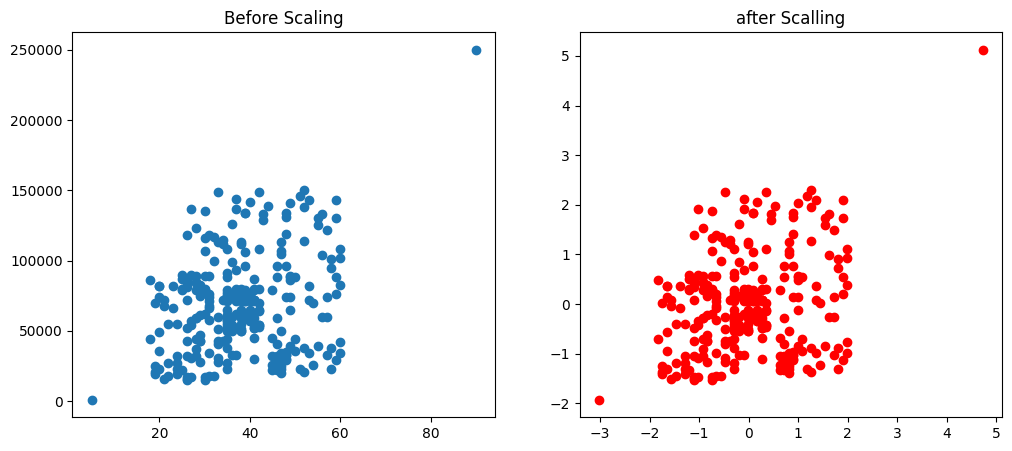

In [117]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2, figsize=(12,5))

ax1.scatter(x_train['Age'] , x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Age'] , x_train_scaled['EstimatedSalary'] , color = 'red')
ax2.set_title("after Scalling")
plt.show()